# 1. Importing packages

In [1]:
# Import all necessary packages
from pyomo.environ import *
import math
import matplotlib.pyplot as plt
import numpy as np

# 2. Defining de variables

In [2]:
# Create a concrete model instance
model = ConcreteModel()

# Time points (0 to 5 seconds)
model.T = RangeSet(0, 5)
# Time intervals (0 to 4)
model.I = RangeSet(0, 4)

# Time step duration
model.dt = Param(initialize=1.0)

# Value of sin(t) at the start of each interval (t_i = i * dt)
model.sin_t = Param(model.I, initialize={i: math.sin(i * model.dt) for i in model.I})

# 3. Assigning decision variables

In [3]:
# Position (x, y) at each time point
model.x = Var(model.T, within=Reals, initialize=0.0)   # Position in x
model.y = Var(model.T, within=Reals, initialize=0.0)   # Position in y

# Velocity (vx, vy) during each time interval - indexed by INTERVALS (model.I)
model.vx = Var(model.I, within=Reals, initialize=1.0) # Velocity in x over interval i
model.vy = Var(model.I, within=Reals, initialize=1.0) # Velocity in y over interval i

# 4. Establishing Constraints

In [4]:
# Constraint 1: Fixing initial positions (0,0)
model.x[0].fix(0.0)
model.y[0].fix(0.0)

# Constraint 2: Final position constraint (10,10)
model.final_x_constr = Constraint(expr=model.x[5] == 10.0)
model.final_y_constr = Constraint(expr=model.y[5] == 10.0)

# Motion constraints (discrete numerical integration)
model.x_update_constr = Constraint(model.I, rule=lambda model, i: model.x[i+1] == model.x[i] + model.vx[i] * model.dt)
model.y_update_constr = Constraint(model.I, rule=lambda model, i: model.y[i+1] == model.y[i] + model.vy[i] * model.dt)

# Objective function: Minimize total energy
model.energy = Objective(expr=sum((model.vx[i]**2 + model.vy[i]**2 + model.sin_t[i]) * model.dt for i in model.I),
                         sense=minimize) # Use pyo.minimize for consistency

# 5. Solving the model and printing it results

In [5]:
# Create an instance of the Ipopt solver
solver = SolverFactory('ipopt')

# Solve the Model
print("Solving the model...")
results = solver.solve(model, tee=True)


# Display Results
print("\n\n--------- Results ---------\n")

# Solution status
print("Solver status:", results.solver.status)
print("Termination condition:", results.solver.termination_condition)

# Position on time
print("\nTrajectory (Position):")
print(" Time | Position (x, y)")
print("------|---------------")
for i in model.T:
    print(f"  {i}s  | ({value(model.x[i]):.4f}, {value(model.y[i]):.4f})")

# Velocity on time
print("\nVelocities per Interval:")
print("   Interval  | Velocity (vx, vy)")
print("-------------|-----------------")
for i in model.I:
     print(f"{i} ({i}s to {i+1}s) | ({value(model.vx[i]):.4f}, {value(model.vy[i]):.4f})")

# Objective function value (minimum energy)
print(f"\nMinimum energy: {value(model.energy):.2f}")

Solving the model...
Ipopt 3.14.17: 

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

This is Ipopt version 3.14.17, running with linear solver MUMPS 5.7.3.

Number of nonzeros in equality constraint Jacobian...:       30
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:       10

Total number of variables............................:       20
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................: 

# 6. Plotting graphs

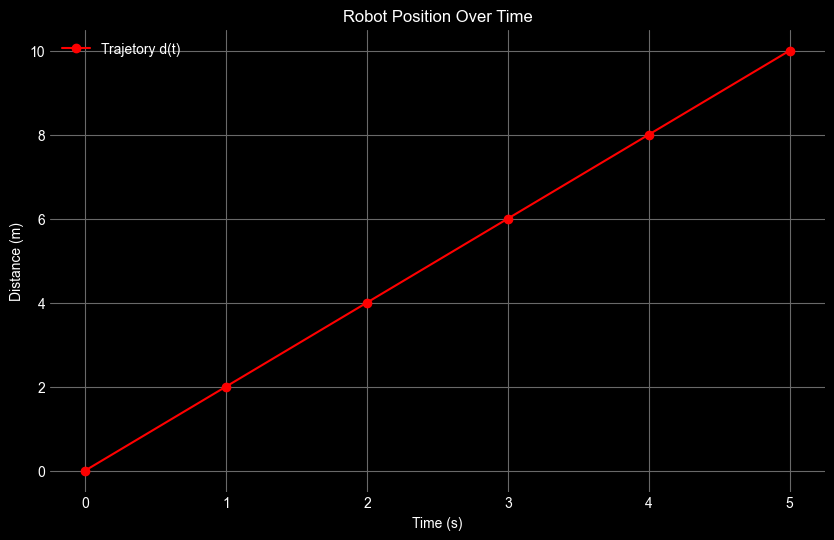

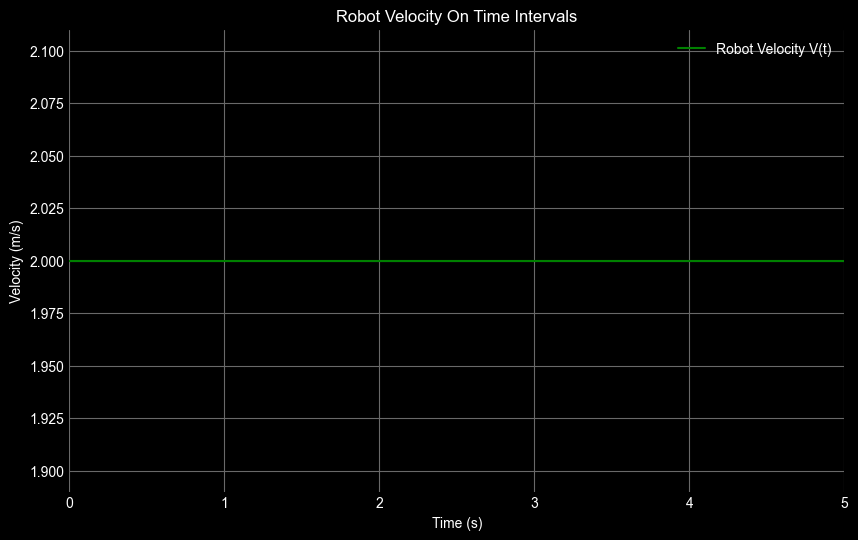

In [6]:
# Extract data from the solved model
time_points = list(model.T)
x_positions = [value(model.x[t]) for t in model.T]
y_positions = [value(model.y[t]) for t in model.T]

# Velocities are per interval, indexed by model.I (0 to 4)
interval_starts = list(model.I)
vx_velocities = [value(model.vx[i]) for i in model.I]
vy_velocities = [value(model.vy[i]) for i in model.I]

# Set a dark style or manually configure
plt.style.use('seaborn-v0_8-darkgrid') # Start with a dark grid style
# Further manual adjustments for pure black background and white text
plt.rcParams['figure.facecolor'] = 'black'
plt.rcParams['axes.facecolor'] = 'black'
plt.rcParams['text.color'] = 'white'
plt.rcParams['axes.labelcolor'] = 'white'
plt.rcParams['xtick.color'] = 'white'
plt.rcParams['ytick.color'] = 'white'
plt.rcParams['axes.titlecolor'] = 'white'
plt.rcParams['grid.color'] = 'dimgray'
plt.rcParams['legend.facecolor'] = 'black'
plt.rcParams['legend.edgecolor'] = 'white'

# Plot 2: Position vs Time (x and y)
plt.figure(figsize=(10, 6))
plt.plot(time_points, x_positions, marker='o', linestyle='-', color='red', label='Trajetory d(t)')
plt.title('Robot Position Over Time')
plt.xlabel('Time (s)')
plt.ylabel('Distance (m)')
plt.legend()
plt.grid(True)
plt.show()

# Plot 3: Velocity vs Time (vx and vy)
velocity_time_points = np.append(interval_starts, time_points[-1])

plt.figure(figsize=(10, 6))
plt.step(velocity_time_points, np.append(vx_velocities, vx_velocities[-1]), where='post', color='green', label='Robot Velocity V(t)')

plt.title('Robot Velocity On Time Intervals')
plt.xlabel('Time (s)')
plt.ylabel('Velocity (m/s)')
plt.legend()
plt.grid(True)
plt.xlim(0, 5) # Limit x-axis to the 5 seconds
plt.show()

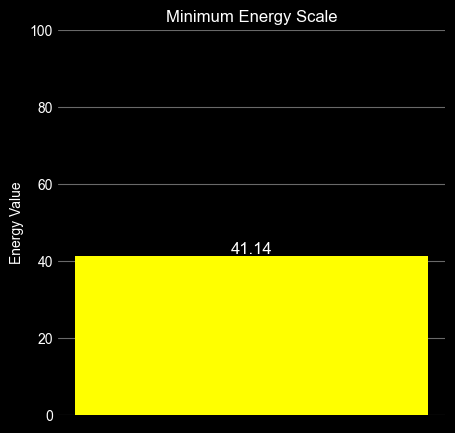

In [7]:
# The minimum energy value from your output and the scale maximum
minimum_energy = value(model.energy)

# Set a dark style or manually configure
plt.style.use('seaborn-v0_8-darkgrid') # Start with a dark grid style
# Further manual adjustments for pure black background and white text
plt.rcParams['figure.facecolor'] = 'black'
plt.rcParams['axes.facecolor'] = 'black'
plt.rcParams['text.color'] = 'white'
plt.rcParams['axes.labelcolor'] = 'white'
plt.rcParams['xtick.color'] = 'white'
plt.rcParams['ytick.color'] = 'white'
plt.rcParams['axes.titlecolor'] = 'white'
plt.rcParams['grid.color'] = 'dimgray' # Keep grid lines visible but not too bright
plt.rcParams['legend.facecolor'] = 'black' # Although no legend here, good practice
plt.rcParams['legend.edgecolor'] = 'white' # Although no legend here, good practice

# Create a figure and a single axis
fig, ax = plt.subplots(figsize=(5, 5))

# Create a vertical bar
x_pos = [0]
height = [minimum_energy]

ax.bar(x_pos, height, width=0.5, color='yellow')

# Set the y-axis limits from 0 to scale_max (100)
ax.set_ylim(0, 100)

# Add the numerical value as text on the bar
# Removed the 'padding' parameter
ax.text(x_pos[0], minimum_energy, f'{minimum_energy:.2f}',
        ha='center', # Horizontal alignment center
        va='bottom', # Vertical alignment bottom (place text above the bar)
        color='white',
        fontsize=12)

# Set title and labels
ax.set_title('Minimum Energy Scale')
ax.set_ylabel('Energy Value')
ax.set_xticks([]) # Hide x-axis ticks and labels as there's only one bar

# Set the figure and axes background color explicitly
fig.patch.set_facecolor('black')
ax.set_facecolor('black')

# Ensure grid is visible and behind the bar
ax.set_axisbelow(True)

plt.show()